<a href="https://colab.research.google.com/github/ldfha/RotemAI/blob/main/projects/pro13cnn/cnn11net_expand.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 모듈의 효율성 향상을 위해 네트워크의 확장
# fashion mnist로 1) Conv + Dense, 2) Conv + Pooling + Dense, 3) 유명 모델의 네트워크
# 사용하여 모델 작성 후 성능 비교

import tensorflow as tf

fashion_mnist = tf.keras.datasets.fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
print(x_train.shape, y_train.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28) (60000,)


(60000, 28, 28) (10000, 28, 28)
(60000, 28, 28, 1) (10000, 28, 28, 1)


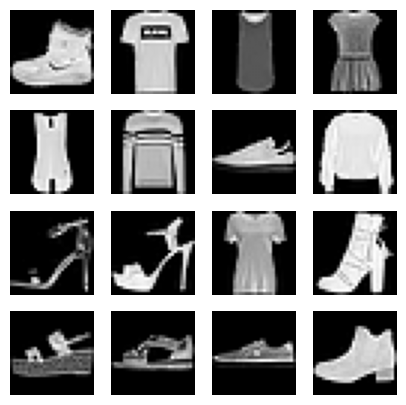

[9 0 0 3 0 2 7 2 5 5 0 9 5 5 7 9]


In [2]:
x_train = x_train / 255.0  # 정규화
x_test = x_test / 255.0

# reshape 이전
print(x_train.shape, x_test.shape)    # (60000, 28, 28) (10000, 28, 28)

# reshape 이후
x_train = x_train.reshape(-1, 28, 28, 1)  # 흑백
x_test = x_test.reshape(-1, 28, 28, 1)
print(x_train.shape, x_test.shape)    # (60000, 28, 28, 1) (10000, 28, 28, 1)

# 데이터 확인 (시각화)
import matplotlib.pyplot as plt
plt.figure(figsize=(5, 5))
for c in range(16):
  plt.subplot(4, 4, c + 1)
  plt.imshow(x_train[c].reshape(28, 28), cmap='gray')
  plt.axis('off')
plt.show()

print(y_train[:16])

In [3]:
# 1) Conv + Dense 신경망 모델 정의
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(filters=16, kernel_size=(3, 3), strides=1),
    tf.keras.layers.Conv2D(filters=32, kernel_size=(3, 3), strides=1),
    tf.keras.layers.Conv2D(filters=64, kernel_size=(3, 3), strides=1),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(10, activation='softmax')
])

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 22, 22, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,982,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,008,234 (7.66 MB)

 Trainable params: 2,008,234 (7.66 MB)

 Non-trainable params: 0 (0.00 B)

None


In [4]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=15, validation_split=0.25, verbose=2)

loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f'loss: {loss:.4f}, accuracy: {acc:.4f}')

Epoch 1/15
1407/1407 - 17s - 12ms/step - accuracy: 0.7726 - loss: 0.6493 - val_accuracy: 0.8417 - val_loss: 0.4393
Epoch 2/15
1407/1407 - 6s - 5ms/step - accuracy: 0.8300 - loss: 0.4860 - val_accuracy: 0.8557 - val_loss: 0.4035
Epoch 3/15
1407/1407 - 7s - 5ms/step - accuracy: 0.8430 - loss: 0.4437 - val_accuracy: 0.8570 - val_loss: 0.3900
Epoch 4/15
1407/1407 - 6s - 4ms/step - accuracy: 0.8527 - loss: 0.4125 - val_accuracy: 0.8573 - val_loss: 0.3954
Epoch 5/15
1407/1407 - 10s - 7ms/step - accuracy: 0.8594 - loss: 0.3920 - val_accuracy: 0.8661 - val_loss: 0.3780
Epoch 6/15
1407/1407 - 7s - 5ms/step - accuracy: 0.8644 - loss: 0.3768 - val_accuracy: 0.8717 - val_loss: 0.3661
Epoch 7/15
1407/1407 - 6s - 4ms/step - accuracy: 0.8682 - loss: 0.3613 - val_accuracy: 0.8660 - val_loss: 0.3781
Epoch 8/15
1407/1407 - 7s - 5ms/step - accuracy: 0.8728 - loss: 0.3471 - val_accuracy: 0.8651 - val_loss: 0.3756
Epoch 9/15
1407/1407 - 6s - 4ms/step - accuracy: 0.8778 - loss: 0.3346 - val_accuracy: 0.8669

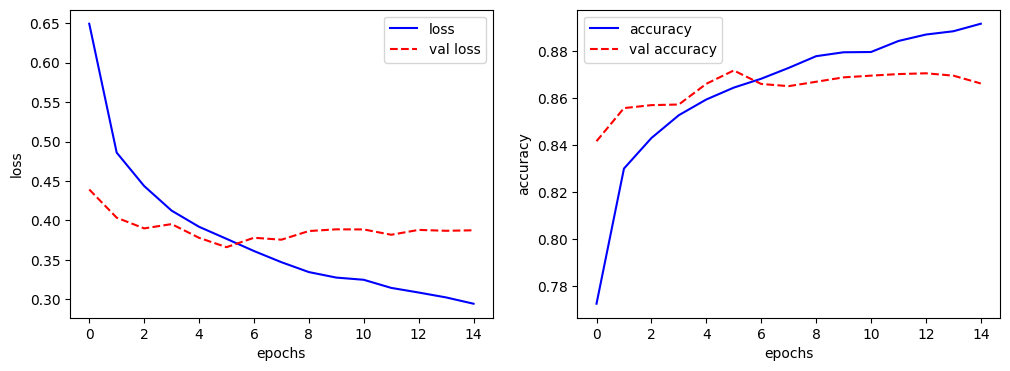

In [5]:
# 성능 시각화
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], 'b-', label='loss')
plt.plot(history.history['val_loss'], 'r--', label='val loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], 'b-', label='accuracy')
plt.plot(history.history['val_accuracy'], 'r--', label='val accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

In [6]:
# 2) Conv + Pooling + Dense 신경망 모델 정의
model2 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(filters=16, kernel_size=(3, 3), strides=1),
    tf.keras.layers.MaxPool2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(filters=32, kernel_size=(3, 3), strides=1),
    tf.keras.layers.MaxPool2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(filters=64, kernel_size=(3, 3), strides=1),
    tf.keras.layers.MaxPool2D(pool_size=(2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(10, activation='softmax')
])

print(model2.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 3, 3, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,866 (116.66 KB)

 Trainable params: 29,866 (116.66 KB)

 Non-trainable params: 0 (0.00 B)

None


In [7]:
model2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model2.fit(x_train, y_train, epochs=15, validation_split=0.25, verbose=2)

loss, acc = model2.evaluate(x_test, y_test, verbose=0)
print(f'loss: {loss:.4f}, accuracy: {acc:.4f}')

Epoch 1/15
1407/1407 - 14s - 10ms/step - accuracy: 0.7166 - loss: 0.7859 - val_accuracy: 0.7931 - val_loss: 0.5481
Epoch 2/15
1407/1407 - 5s - 4ms/step - accuracy: 0.8054 - loss: 0.5412 - val_accuracy: 0.8367 - val_loss: 0.4489
Epoch 3/15
1407/1407 - 6s - 4ms/step - accuracy: 0.8312 - loss: 0.4744 - val_accuracy: 0.8483 - val_loss: 0.4147
Epoch 4/15
1407/1407 - 5s - 4ms/step - accuracy: 0.8482 - loss: 0.4321 - val_accuracy: 0.8536 - val_loss: 0.4051
Epoch 5/15
1407/1407 - 6s - 4ms/step - accuracy: 0.8592 - loss: 0.4000 - val_accuracy: 0.8609 - val_loss: 0.3802
Epoch 6/15
1407/1407 - 5s - 4ms/step - accuracy: 0.8660 - loss: 0.3775 - val_accuracy: 0.8695 - val_loss: 0.3627
Epoch 7/15
1407/1407 - 7s - 5ms/step - accuracy: 0.8756 - loss: 0.3541 - val_accuracy: 0.8711 - val_loss: 0.3598
Epoch 8/15
1407/1407 - 5s - 4ms/step - accuracy: 0.8799 - loss: 0.3377 - val_accuracy: 0.8737 - val_loss: 0.3462
Epoch 9/15
1407/1407 - 7s - 5ms/step - accuracy: 0.8830 - loss: 0.3233 - val_accuracy: 0.8689 

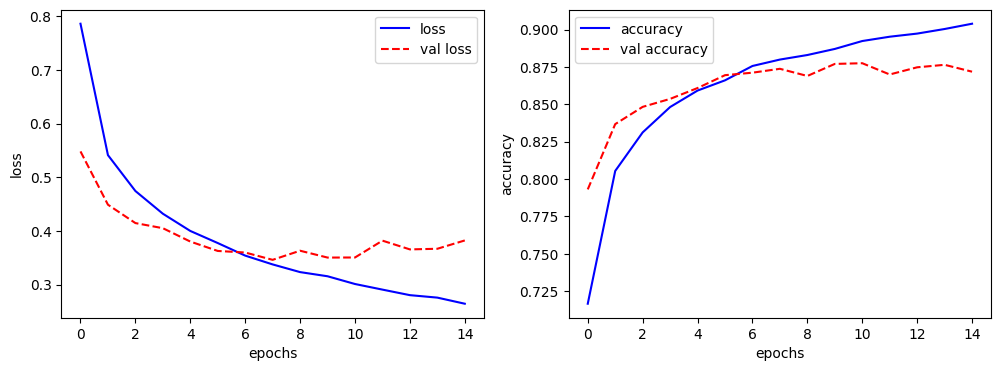

In [8]:
# 성능 시각화
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], 'b-', label='loss')
plt.plot(history.history['val_loss'], 'r--', label='val loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], 'b-', label='accuracy')
plt.plot(history.history['val_accuracy'], 'r--', label='val accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

In [9]:
# 유명 모델(vggnet)의 네트워크의 일부 구조를 사용
model3 = tf.keras.Sequential([
    tf.keras.layers.Conv2D(input_shape=(28,28,1), kernel_size=(3,3), filters=32, padding='same', activation='relu'),
    tf.keras.layers.Conv2D(kernel_size=(3,3), filters=64, padding='same', activation='relu'),
    tf.keras.layers.MaxPool2D(pool_size=(2,2)),
    tf.keras.layers.Dropout(rate=0.5),
    tf.keras.layers.Conv2D(kernel_size=(3,3), filters=128, padding='same', activation='relu'),
    tf.keras.layers.Conv2D(kernel_size=(3,3), filters=256, padding='valid', activation='relu'),
    tf.keras.layers.MaxPool2D(pool_size=(2,2)),
    tf.keras.layers.Dropout(rate=0.5),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=512, activation='relu'),
    tf.keras.layers.Dropout(rate=0.5),
    tf.keras.layers.Dense(units=256, activation='relu'),
    tf.keras.layers.Dropout(rate=0.5),
    tf.keras.layers.Dense(units=10, activation='softmax')
])

print(model3.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │     4,719,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,240,842 (19.99 MB)

 Trainable params: 5,240,842 (19.99 MB)

 Non-trainable params: 0 (0.00 B)

None


In [10]:
model3.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model3.fit(x_train, y_train, epochs=15, validation_split=0.25, verbose=2)

loss, acc = model3.evaluate(x_test, y_test, verbose=0)
print(f'loss: {loss:.4f}, accuracy: {acc:.4f}')

Epoch 1/15
1407/1407 - 25s - 18ms/step - accuracy: 0.7912 - loss: 0.5726 - val_accuracy: 0.8703 - val_loss: 0.3480
Epoch 2/15
1407/1407 - 11s - 8ms/step - accuracy: 0.8685 - loss: 0.3710 - val_accuracy: 0.8908 - val_loss: 0.2921
Epoch 3/15
1407/1407 - 11s - 8ms/step - accuracy: 0.8837 - loss: 0.3249 - val_accuracy: 0.8826 - val_loss: 0.2969
Epoch 4/15
1407/1407 - 11s - 8ms/step - accuracy: 0.8921 - loss: 0.3029 - val_accuracy: 0.9107 - val_loss: 0.2380
Epoch 5/15
1407/1407 - 11s - 8ms/step - accuracy: 0.8961 - loss: 0.2876 - val_accuracy: 0.9137 - val_loss: 0.2339
Epoch 6/15
1407/1407 - 12s - 9ms/step - accuracy: 0.9013 - loss: 0.2743 - val_accuracy: 0.9194 - val_loss: 0.2261
Epoch 7/15
1407/1407 - 11s - 8ms/step - accuracy: 0.9052 - loss: 0.2648 - val_accuracy: 0.9163 - val_loss: 0.2333
Epoch 8/15
1407/1407 - 11s - 8ms/step - accuracy: 0.9069 - loss: 0.2589 - val_accuracy: 0.9241 - val_loss: 0.2112
Epoch 9/15
1407/1407 - 11s - 8ms/step - accuracy: 0.9077 - loss: 0.2566 - val_accuracy:

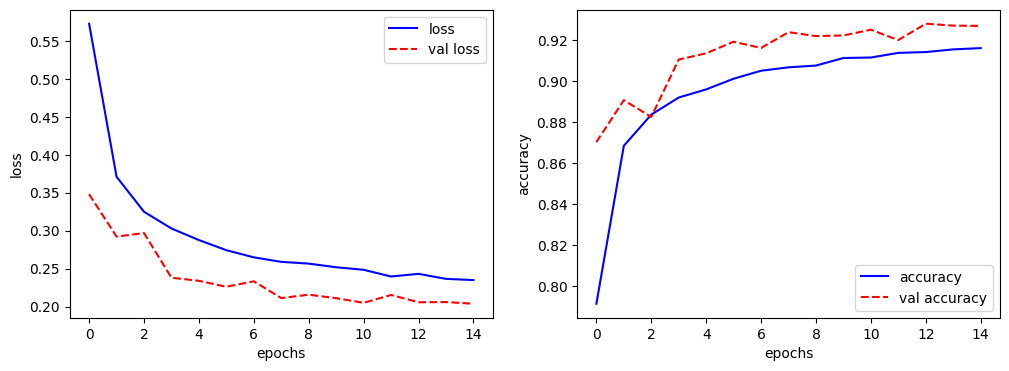

In [11]:
# 성능 시각화
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], 'b-', label='loss')
plt.plot(history.history['val_loss'], 'r--', label='val loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], 'b-', label='accuracy')
plt.plot(history.history['val_accuracy'], 'r--', label='val accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()